In [1]:
import MLJ as mlj
import matplotlib.pyplot as plt
import numpy as np

"""Configuration"""
n_temps = 10
mlj.config.temperatures_K = np.linspace(50, 350, n_temps)
mlj.config.photon_energies = np.linspace(0.8, 2.0, 300)

"""Define the states"""
gs = mlj.State(name="S0", energy=0.0)
le = mlj.State(name="LE", energy=1.5, disorder_sigma=0.02)
ct = mlj.State(name="CT", energy=1.35, disorder_sigma=0.02)

"""Define the transitions"""
trans_LE = mlj.Transition(le, gs, lambda_outer=0.05)
trans_CT = mlj.Transition(ct, gs, oscillator_strength=3)
trans_LECT = mlj.Transition(le, ct, k_transfer=np.ones(n_temps))

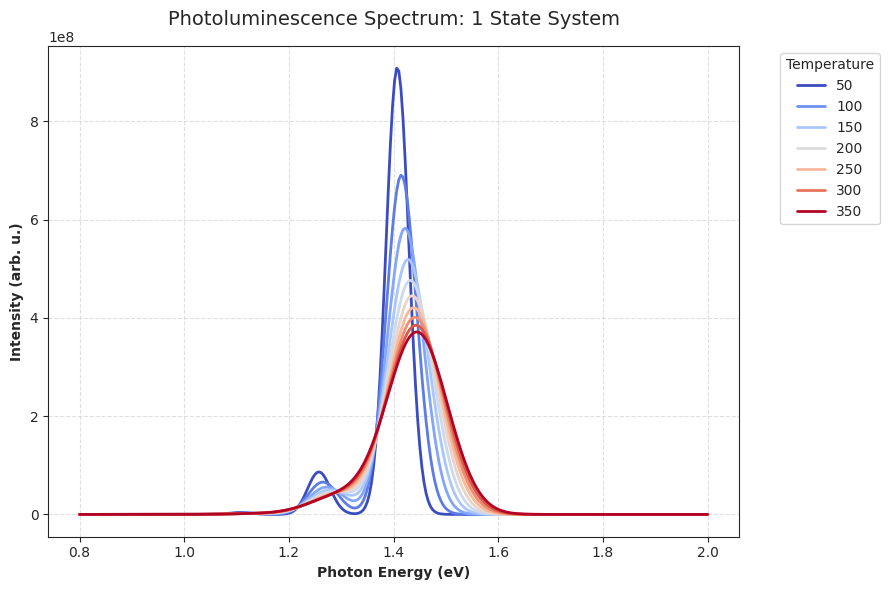

In [2]:
"""Generate the system  -- example one state"""
one_state_system = mlj.StateSystem([trans_LE])

mlj.plot_PL(one_state_system)
plt.show()

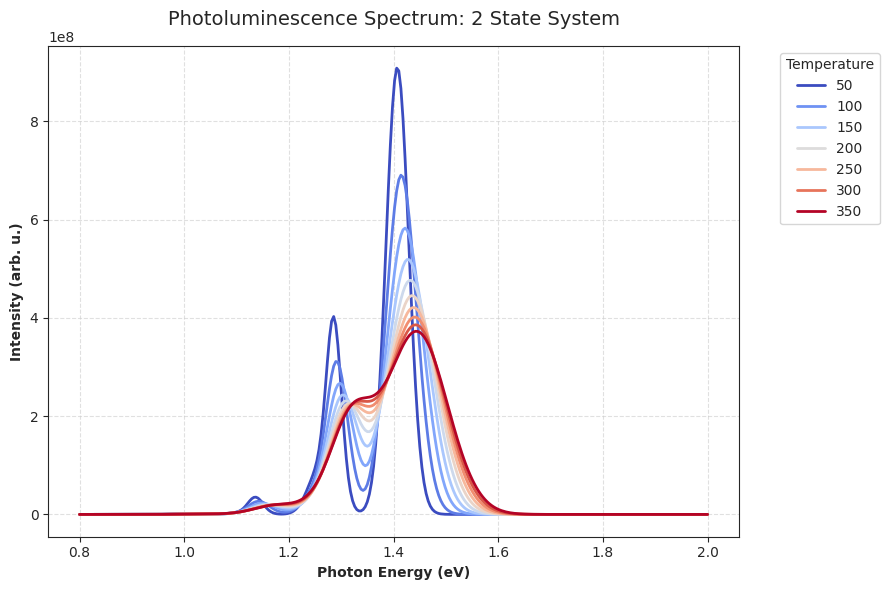

In [3]:
"""Generate the system -- example 2 states"""
two_state_system = mlj.StateSystem([trans_LE, trans_CT, trans_LECT])

mlj.plot_PL(two_state_system)
plt.show()

In [8]:
"""Reading out the rates"""

print(two_state_system.sorted_states)
rates = two_state_system.rates

rates_CT = rates[0]
rates_LE = rates[1]

print(f"Total Recombination = {rates_LE.rate_recombination_total}")

[State(Name='CT', Energy=1.3500 eV), State(Name='LE', Energy=1.5000 eV)]
Total Recombination = [86162125.15270707 87560259.62218714 88802798.77266192 89781936.17382526
 90539059.11316003 91143329.0270742  91657033.90170501 92129838.80029911
 92598838.16139422 93090045.74578315]


Non-radiative rate = [311.31213389 375.20849222]
Radiative rate = [90855817.64122483 92362575.92175767]
Total Recombination = [90856128.95335872 92362951.13024989]


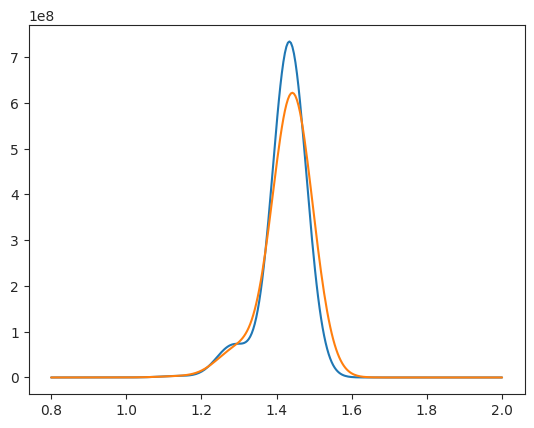

In [6]:
rates = mlj.Rates(
    transition=trans_LE,
    temperatures=np.array([200, 300]),
)

print(f"Non-radiative rate = {rates.rate_non_radiative_total}")
print(f"Radiative rate = {rates.rate_radiative_total}")
print(f"Total Recombination = {rates.rate_recombination_total}")

plt.plot(mlj.config.photon_energies, rates.rate_radiative_spectral)
plt.show()